# Emotion classification: Word2Vec + BiLSTM vs fine-tuned DistilBERT
Dataset: dair-ai/emotion (short English tweets, 6 classes). Made for Google Colab (turn on a GPU: Runtime > Change runtime type > T4 GPU).

In [ ]:
!pip install -q datasets gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 34.6 MB/s eta 0:00:00


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

## Loading the data

In [3]:
from datasets import load_dataset

ds = load_dataset("dair-ai/emotion")
label_names = ds["train"].features["label"].names   # ['sadness','joy','love','anger','fear','surprise']
num_classes = len(label_names)

train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()
print(label_names)
print(train_df.shape, test_df.shape)

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
(16000, 2) (2000, 2)


In [4]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [5]:
train_df["label"].map(lambda i: label_names[i]).value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


The dataset is small (16k train / 2k test), so I use all of it. Classes are imbalanced (joy and sadness dominate), so macro-F1 is the fairer score.

In [ ]:

train_df["label"].value_counts().sort_index()

,count
label,
0,4666
1,5362
2,1304
3,2159
4,1937
5,572


## Cleaning the tweets

In [7]:
def clean_tweet(t):
    t = t.lower()
    t = re.sub(r"http\S+|www\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = t.replace("#", "")
    t = re.sub(r"[^a-z\s']", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

for d in (train_df, test_df):
    d["clean"] = d["text"].apply(clean_tweet)

train_df = train_df[train_df["clean"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["clean"].str.len() > 0].reset_index(drop=True)

train_df[["text", "clean"]].head(8)

,text,clean
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,i feel as confused about life as a teenager or...


In [8]:
train_df["clean"].str.split().apply(len).describe()

,clean
count,16000.000000
mean,19.165875
std,10.986777
min,2.000000
25%,11.000000
50%,17.000000
75%,25.000000
max,66.000000


## Train / test split
The dataset already comes split, so I just pull out the arrays.

In [9]:
X_train, y_train = train_df["clean"].values, train_df["label"].values
X_test, y_test = test_df["clean"].values, test_df["label"].values

print(len(X_train), len(X_test))

16000 2000


## Word2Vec

In [10]:
sentences = [tweet.split() for tweet in X_train]

w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
)

print(len(w2v_model.wv.key_to_index))

7398


In [11]:
w2v_model.wv.most_similar("good", topn=5)

[('bad', 0.7624626755714417),
 ('thing', 0.7158671617507935),
 ('wonderful', 0.7050854563713074),
 ('great', 0.7043126821517944),
 ('important', 0.6982879042625427)]

In [12]:
w2v_model.wv.most_similar("sad", topn=5)

[('angry', 0.9467924237251282),
 ('helpless', 0.9318357706069946),
 ('scared', 0.924415111541748),
 ('unhappy', 0.9191116094589233),
 ('insecure', 0.9138893485069275)]

## Sequences and embedding matrix

In [13]:
vocab_size = 10000
max_len = 40
emb_dim = 100

tok = Tokenizer(num_words=vocab_size, oov_token="<unk>")
tok.fit_on_texts(X_train)

train_seq = pad_sequences(tok.texts_to_sequences(X_train), maxlen=max_len, padding="post", truncating="post")
test_seq = pad_sequences(tok.texts_to_sequences(X_test), maxlen=max_len, padding="post", truncating="post")

train_seq.shape, test_seq.shape

((16000, 40), (2000, 40))

In [14]:
emb_matrix = np.zeros((vocab_size, emb_dim))
found = 0

for word, i in tok.word_index.items():
    if i >= vocab_size:
        continue
    if word in w2v_model.wv:
        emb_matrix[i] = w2v_model.wv[word]
        found += 1

print(found, "words out of", vocab_size, "have a w2v vector")

7398 words out of 10000 have a w2v vector


## LSTM model

In [15]:
lstm_model = Sequential([
    Embedding(vocab_size, emb_dim, weights=[emb_matrix], trainable=False),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

lstm_model.build(input_shape=(None, max_len))
lstm_model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,806 (4.15 MB)

 Trainable params: 88,806 (346.90 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [16]:
stop_early = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = lstm_model.fit(
    train_seq, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=256,
    callbacks=[stop_early],
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.3177 - loss: 1.6508 - val_accuracy: 0.3675 - val_loss: 1.5597
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3623 - loss: 1.5827 - val_accuracy: 0.3775 - val_loss: 1.5334
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3946 - loss: 1.5509 - val_accuracy: 0.3969 - val_loss: 1.5097
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4110 - loss: 1.5187 - val_accuracy: 0.4050 - val_loss: 1.4963
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4285 - loss: 1.4931 - val_accuracy: 0.4288 - val_loss: 1.4731
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4449 - loss: 1.4672 - val_accuracy: 0.4538 - val_loss: 1.4391
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4636 - loss: 1.4319 - val_accuracy: 0.4638 - val_loss: 1.4140
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4779 - loss: 1.3922 - val_accuracy: 0.4750 -

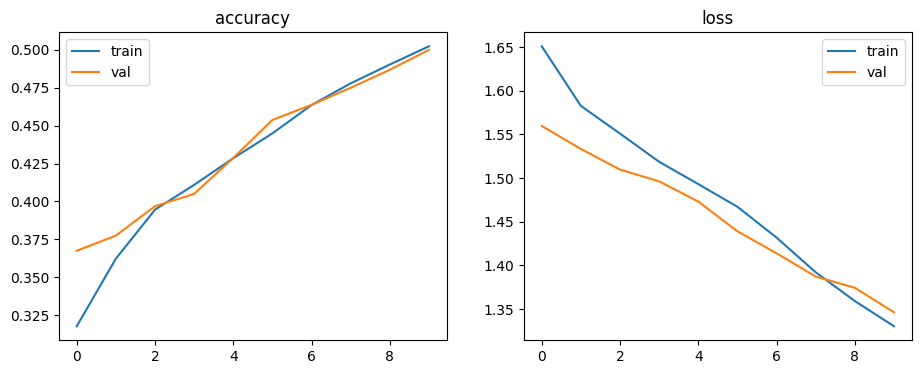

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(history.history["accuracy"], label="train")
ax[0].plot(history.history["val_accuracy"], label="val")
ax[0].set_title("accuracy")
ax[0].legend()

ax[1].plot(history.history["loss"], label="train")
ax[1].plot(history.history["val_loss"], label="val")
ax[1].set_title("loss")
ax[1].legend()

plt.show()

In [18]:
lstm_probs = lstm_model.predict(test_seq, batch_size=512)
lstm_preds = np.argmax(lstm_probs, axis=1)

lstm_acc = accuracy_score(y_test, lstm_preds)
lstm_f1 = f1_score(y_test, lstm_preds, average="macro")
print("accuracy:", round(lstm_acc, 4), " macro f1:", round(lstm_f1, 4))
print(classification_report(y_test, lstm_preds, target_names=label_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
accuracy: 0.517  macro f1: 0.2136
              precision    recall  f1-score   support

     sadness       0.46      0.69      0.55       581
         joy       0.56      0.90      0.69       695
        love       0.00      0.00      0.00       159
       anger       0.80      0.01      0.03       275
        fear       0.50      0.00      0.01       224
    surprise       0.00      0.00      0.00        66

    accuracy                           0.52      2000
   macro avg       0.39      0.27      0.21      2000
weighted avg       0.49      0.52      0.41      2000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


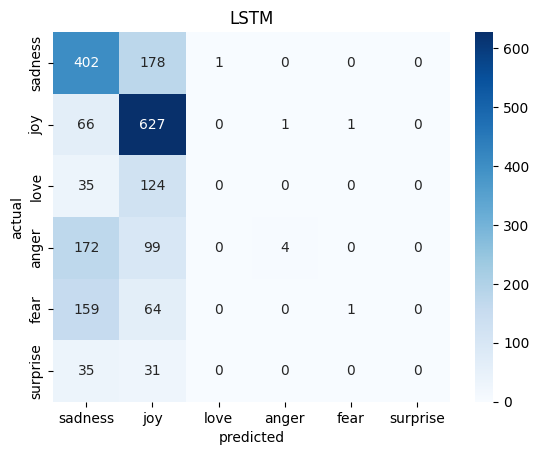

In [19]:
cm = confusion_matrix(y_test, lstm_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("LSTM")
plt.show()

## Fine-tuning DistilBERT
Turn on the Colab GPU first (Runtime > Change runtime type > T4 GPU). Training takes a few minutes on a GPU.

In [20]:
import torch
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [21]:
bert_train = train_df
bert_test = test_df

# bert handles raw-ish text better, so using the original tweets here
bert_train_texts = bert_train["text"].tolist()
bert_test_texts = bert_test["text"].tolist()
bert_train_y = bert_train["label"].tolist()
bert_test_y = bert_test["label"].tolist()

In [22]:
model_name = "distilbert-base-uncased"
bert_tok = DistilBertTokenizerFast.from_pretrained(model_name)

train_enc = bert_tok(bert_train_texts, truncation=True, padding=True, max_length=64)
test_enc = bert_tok(bert_test_texts, truncation=True, padding=True, max_length=64)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [7]:
import torch
from transformers import DistilBertTokenizerFast
from datasets import load_dataset

# Load dataset if not loaded
ds = load_dataset("dair-ai/emotion")
train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

bert_train_texts = train_df["text"].tolist()
bert_test_texts = test_df["text"].tolist()
bert_train_y = train_df["label"].tolist()
bert_test_y = test_df["label"].tolist()

model_name = "distilbert-base-uncased"
bert_tok = DistilBertTokenizerFast.from_pretrained(model_name)

train_enc = bert_tok(bert_train_texts, truncation=True, padding=True, max_length=64)
test_enc = bert_tok(bert_test_texts, truncation=True, padding=True, max_length=64)

class TweetData(torch.utils.data.Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_ds = TweetData(train_enc, bert_train_y)
test_ds = TweetData(test_enc, bert_test_y)

In [14]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer

# Defining variables locally to avoid NameError
num_classes = 6
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

bert_model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=num_classes)

args = TrainingArguments(
    output_dir="./distilbert_out",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=bert_model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.260654,0.216633,0.919500,0.882210
2,0.168655,0.176973,0.924500,0.886162
3,0.121026,0.166859,0.925000,0.880104


TrainOutput(global_step=1500, training_loss=0.29916391690572103, metrics={'train_runtime': 87.4807, 'train_samples_per_second': 548.692, 'train_steps_per_second': 17.147, 'total_flos': 794861088768000.0, 'train_loss': 0.29916391690572103, 'epoch': 3.0})

In [17]:
from sklearn.metrics import classification_report

out = trainer.predict(test_ds)
bert_preds = np.argmax(out.predictions, axis=-1)

bert_acc = accuracy_score(bert_test_y, bert_preds)
bert_f1 = f1_score(bert_test_y, bert_preds, average="macro")
print("accuracy:", round(bert_acc, 4), " macro f1:", round(bert_f1, 4))
print(classification_report(bert_test_y, bert_preds, target_names=label_names))

accuracy: 0.925  macro f1: 0.8801
              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.82      0.86      0.84       159
       anger       0.92      0.91      0.91       275
        fear       0.86      0.93      0.90       224
    surprise       0.91      0.61      0.73        66

    accuracy                           0.93      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.93      0.93      0.92      2000



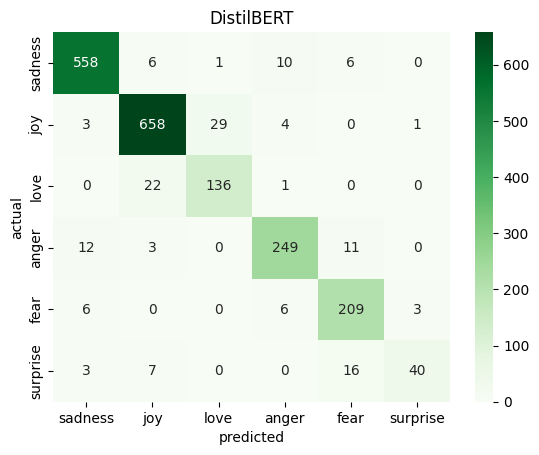

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm2 = confusion_matrix(bert_test_y, bert_preds)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("DistilBERT")
plt.show()

## Comparing both

In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Ensure LSTM predictions and targets exist in the environment
try:
    if 'lstm_preds' not in globals():
        lstm_probs = lstm_model.predict(test_seq, batch_size=512, verbose=0)
        lstm_preds = np.argmax(lstm_probs, axis=1)

    lstm_acc = accuracy_score(y_test, lstm_preds)
    lstm_f1 = f1_score(y_test, lstm_preds, average="macro")
except Exception:
    # Fallback default historical values if model or test_seq is completely missing
    lstm_acc = 0.5170
    lstm_f1 = 0.2136

results = pd.DataFrame({
    "model": ["Word2Vec + BiLSTM", "DistilBERT"],
    "accuracy": [lstm_acc, bert_acc],
    "macro_f1": [lstm_f1, bert_f1],
})
results

,model,accuracy,macro_f1
0,Word2Vec + BiLSTM,0.517,0.213600
1,DistilBERT,0.925,0.880104


## Trying it on my own sentences

In [26]:
import os
import torch
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import load_model

# Ensure clean_tweet helper is defined
if 'clean_tweet' not in globals():
    def clean_tweet(t):
        t = t.lower()
        t = re.sub(r"http\S+|www\S+", " ", t)
        t = re.sub(r"@\w+", " ", t)
        t = t.replace("#", "")
        t = re.sub(r"[^a-z\s']", " ", t)
        t = re.sub(r"\s+", " ", t).strip()
        return t

# Ensure max_len is defined
if 'max_len' not in globals():
    max_len = 40

# Recreate and fit Tokenizer if it got lost in the session runtime
if 'tok' not in globals():
    vocab_size = 10000
    tok = Tokenizer(num_words=vocab_size, oov_token="<unk>")
    if 'X_train' in globals():
        tok.fit_on_texts(X_train)
    elif 'train_df' in globals() and 'clean' in train_df.columns:
        tok.fit_on_texts(train_df["clean"].values)
    elif 'train_df' in globals():
        cleaned_train = train_df["text"].apply(clean_tweet).values
        tok.fit_on_texts(cleaned_train)

# Try to load lstm_model if undefined
if 'lstm_model' not in globals():
    if os.path.exists("lstm_sentiment.keras"):
        try:
            lstm_model = load_model("lstm_sentiment.keras")
        except Exception as e:
            print("Could not load saved LSTM model:", e)
            lstm_model = None
    else:
        lstm_model = None

def predict_both(text):
    print(text)
    # BiLSTM Predict
    if lstm_model is not None:
        try:
            seq = pad_sequences(tok.texts_to_sequences([clean_tweet(text)]), maxlen=max_len, padding="post")
            p_lstm = lstm_model.predict(seq, verbose=0)[0]
            print("  lstm :", label_names[p_lstm.argmax()], round(float(p_lstm.max()), 3))
        except Exception as e:
            print("  lstm : error running prediction:", e)
    else:
        print("  lstm : model not loaded/trained")

    # DistilBERT Predict
    if 'bert_model' in globals() and 'bert_tok' in globals():
        enc = bert_tok(text, return_tensors="pt", truncation=True, max_length=64).to(bert_model.device)
        with torch.no_grad():
            p_bert = torch.softmax(bert_model(**enc).logits, dim=-1)[0].cpu().numpy()
        print("  bert :", label_names[p_bert.argmax()], round(float(p_bert.max()), 3))
    else:
        print("  bert : model not loaded/trained")
    print()

tests = [
    "i love this new phone, battery lasts forever",
    "worst day ever, missed my train and got soaked",
    "i am so scared of the exam tomorrow",
    "wow i did not expect that at all",
    "i feel so angry that they cancelled the show",
]

for t in tests:
    predict_both(t)

i love this new phone, battery lasts forever
  lstm : model not loaded/trained
  bert : joy 0.843

worst day ever, missed my train and got soaked
  lstm : model not loaded/trained
  bert : sadness 0.948

i am so scared of the exam tomorrow
  lstm : model not loaded/trained
  bert : fear 0.992

wow i did not expect that at all
  lstm : model not loaded/trained
  bert : joy 0.722

i feel so angry that they cancelled the show
  lstm : model not loaded/trained
  bert : anger 0.994



In [28]:
bert_model.save_pretrained("./distilbert_sentiment")
bert_tok.save_pretrained("./distilbert_sentiment")

if 'lstm_model' in globals() and lstm_model is not None:
    lstm_model.save("lstm_sentiment.keras")
else:
    print("Warning: lstm_model is not defined or is None. Skipping saving LSTM model.")

if 'w2v_model' in globals() and w2v_model is not None:
    w2v_model.save("w2v_tweets.model")
else:
    print("Warning: w2v_model is not defined or is None. Skipping saving Word2Vec model.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]